In [205]:
import h5py
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
from flymetrics import epochs

from src import loader, vis, timesync
import xarray as xr
from src.plots import plot_PSTH
from src.plots import *
from src.xarray_ops import stack_epochs
from sklearn.decomposition import PCA
import seaborn as sns

In [2]:
# set raw and processed_paths
# define experiment id
exp_id = 'TSeries_20251217-101'

raw_path = io.get_base_path(exp_id,'raw')
processed_path = io.get_base_path(exp_id, 'processed')
print(raw_path)

/Volumes/AhmedLab/princess/data/raw/TSeries_20251217-101


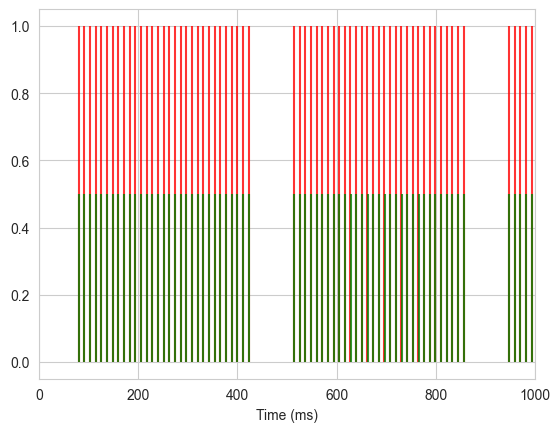

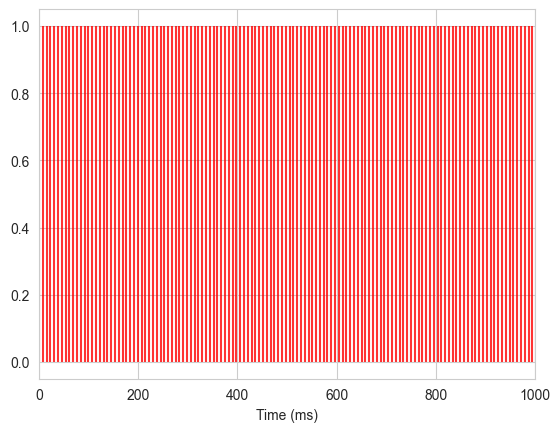

In [3]:
# load in scope timestamp data
scope_timestamps = timesync.extract_scope_timestamps(raw_path, plot=True)
camera_timestamps = timesync.extract_camera_timestamps(raw_path, plot=True)
# load in calcium and spatial data
cluster_labels, signal = io.load_clusters(processed_path)
scope_fr, camera_fr, brain_dim = io.load_acquisition_params(processed_path)

In [145]:
# convert all times to datetime format
# event times
walk_times = [
'00:37',
'00:50',
'01:12',
'2:10',
'2:47',
'8:15',
'8:29',
'9:02',
'11:48',
'11:14'
    ]

# reformat strings into event times in ms
t0 = np.datetime64('2025-01-01T00:00:00')
walk_events = np.asarray([int(e.split(':')[0])*60 + int(e.split(':')[1]) for e in walk_times])
walk_events = (walk_events * 1000).astype('<m8[ms]')
walk_events = t0+walk_events

# organize into dataframe
# epoch_df stores all events of interest
walk_epoch_df = pd.DataFrame(walk_events, columns=['start'])
walk_epoch_df['epoch'] = 'walk' # this just fills in walk into epoch column of each behavior, but should be changed for other behaviors
walk_epoch_df['stop'] = walk_epoch_df['start'] + np.timedelta64(5, 's')
walk_epoch_df

,start,epoch,stop
0,2025-01-01 00:00:37,walk,2025-01-01 00:00:42
1,2025-01-01 00:00:50,walk,2025-01-01 00:00:55
2,2025-01-01 00:01:12,walk,2025-01-01 00:01:17
3,2025-01-01 00:02:10,walk,2025-01-01 00:02:15
4,2025-01-01 00:02:47,walk,2025-01-01 00:02:52
5,2025-01-01 00:08:15,walk,2025-01-01 00:08:20
6,2025-01-01 00:08:29,walk,2025-01-01 00:08:34
7,2025-01-01 00:09:02,walk,2025-01-01 00:09:07
8,2025-01-01 00:11:48,walk,2025-01-01 00:11:53
9,2025-01-01 00:11:14,walk,2025-01-01 00:11:19


In [239]:
flap_times = [
'4:22',
'6:13',
'11:41',
'12:00',
'12:17',
'12:30',
'13:02',
'13:41',
'13:54',
'14:43',
    ]

flap_events = np.asarray([int(e.split(':')[0])*60 + int(e.split(':')[1]) for e in flap_times])
flap_events = (flap_events * 1000).astype('<m8[ms]')
flap_events = t0+flap_events

flap_epoch_df = pd.DataFrame(flap_events, columns=['start'])
flap_epoch_df['epoch'] = 'flap' # this just fills in walk into epoch column of each behavior, but should be changed for other behaviors
flap_epoch_df['stop'] = flap_epoch_df['start'] + np.timedelta64(5, 's')
flap_epoch_df

,start,epoch,stop
0,2025-01-01 00:04:22,flap,2025-01-01 00:04:27
1,2025-01-01 00:06:13,flap,2025-01-01 00:06:18
2,2025-01-01 00:11:41,flap,2025-01-01 00:11:46
3,2025-01-01 00:12:00,flap,2025-01-01 00:12:05
4,2025-01-01 00:12:17,flap,2025-01-01 00:12:22
5,2025-01-01 00:12:30,flap,2025-01-01 00:12:35
6,2025-01-01 00:13:02,flap,2025-01-01 00:13:07
7,2025-01-01 00:13:41,flap,2025-01-01 00:13:46
8,2025-01-01 00:13:54,flap,2025-01-01 00:13:59
9,2025-01-01 00:14:43,flap,2025-01-01 00:14:48


In [242]:
def build_epoch_df(event_list, epoch_name, epoch_duration):
    t0 = np.datetime64('2025-01-01T00:00:00')
    event_arr = np.asarray([int(e.split(':')[0])*60 + int(e.split(':')[1]) for e in event_list])
    event_arr = t0 + (event_arr * 1000).astype('<m8[ms]')

    event_epoch_df = pd.DataFrame(event_arr, columns=['start'])
    event_epoch_df['epoch'] = epoch_name
    event_epoch_df['stop'] = event_epoch_df['start'] + np.timedelta64(epoch_duration, 's')

    return event_epoch_df

In [148]:
# converting scope timestamps into datetime format
t0 = np.datetime64('2025-01-01T00:00:00')
# because scope_timestamps is for single slices, we selected the first slice of the volume to use as our timestamps
# to align to signal timestamps
deltas = np.round(scope_timestamps[::31]).astype('<m8[ms]')
timestamps = t0+deltas

In [150]:
# transform my signal array into xarray with named columns
signal_xary = xr.DataArray(
    data=signal,
    dims=['zposs', 'roi', 'time'],
    coords={'time': timestamps.squeeze()},
)

# transform signal and event times into epoch xarray
walks = stack_epochs(
    xary=signal_xary,
    epochs=['walk'],
    epoch_df=walk_epoch_df,
    start_shift=np.timedelta64(-2, 's'),
    end_shift=np.timedelta64(10, 's'),
    mode='start'
)
walks = walks.squeeze()

# transform signal and event times into epoch xarray
flaps = stack_epochs(
    xary=signal_xary,
    epochs=['flap'],
    epoch_df=flap_epoch_df,
    start_shift=np.timedelta64(-2, 's'),
    end_shift=np.timedelta64(10, 's'),
    mode='start'
)
flaps = flaps.squeeze()

/Users/princesst/projects/maui_codebook/src/xarray_ops.py:158: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'time' ('time',) The recommendation is to set join explicitly for this case.
  trial_stack = xr.concat(
/Users/princesst/projects/maui_codebook/src/xarray_ops.py:158: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'time' ('time',) The recommendation is to set join explicitly for this case.
  trial_stack = xr.concat(


In [151]:
to_pca = signal_xary.stack(poss=['zposs','roi'])
to_pca -= to_pca.mean(dim='time')
to_pca = to_pca.dropna(dim='time', how='any')

[52.84092625 21.54886009  7.99208523  6.47917507  3.0152352   2.19360047
  2.01345658  1.75248117  1.14533399  1.01884595]


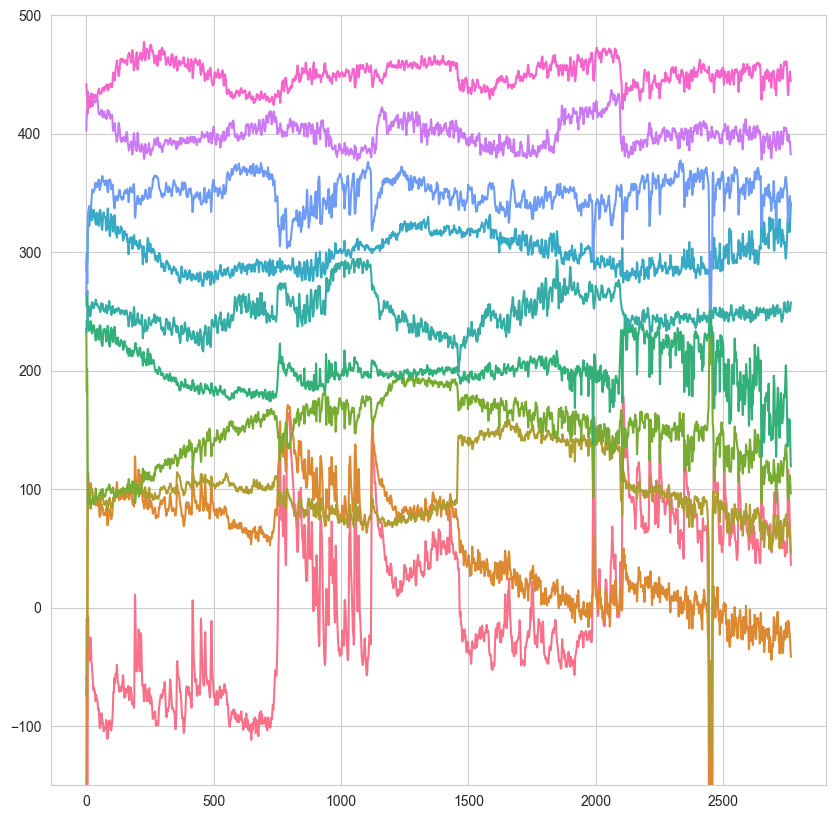

In [211]:
pca = PCA(n_components=10)

# fit my data to the 50 PCA components
all_transformed = pca.fit_transform(to_pca.transpose('time', 'poss'))
print(pca.explained_variance_ / np.sum(pca.explained_variance_)*100)

fig, ax = plt.subplots(figsize=(10,10))
color_list = sns.color_palette('husl', n_colors=10)
yshift = 50
ax.set_ylim(-150,500)
for idx, ind_cluster in enumerate(all_transformed.T):
    ax.plot(ind_cluster +(idx*yshift), color=color_list[idx])

In [174]:
all_transformed
pca_transforms = xr.DataArray(
    data=all_transformed,
    dims=['time', 'pcs'],
    coords={'time': timestamps.squeeze()}
)
pca_transforms

<xarray.DataArray (time: 2767, pcs: 10)> Size: 221kB
array([[-516.1140409 , -199.36906015, -174.39566018, ...,  -86.71878954,
           2.50992851,   -7.87377067],
       [-378.52710036, -133.62587894, -128.01012675, ...,  -68.43769589,
          10.97118525,  -13.16622052],
       [-315.89027081, -108.59800197, -108.94267699, ...,  -54.62054348,
          18.81623986,  -17.14040634],
       ...,
       [  53.74362144,  -84.51610727,  -45.55369647, ...,   -9.95195624,
         -13.13268392,   -2.51560017],
       [  42.64722062,  -89.52421534,  -51.41072906, ...,  -11.13681253,
         -16.32567315,   -5.03479382],
       [  35.87154459,  -91.65209887,  -54.0168205 , ...,   -8.51856137,
         -17.51631598,   -5.4435799 ]], shape=(2767, 10))
Coordinates:
  * time     (time) datetime64[ms] 22kB 2025-01-01T00:00:00.080000 ... 2025-0...
Dimensions without coordinates: pcs

In [250]:
pca_walks_onset = stack_epochs(
    xary=pca_transforms,
    epochs=['walk'],
    epoch_df=walk_epoch_df,
    start_shift=np.timedelta64(-2, 's'),
    end_shift=np.timedelta64(5, 's'),
)
pca_flaps_onset = stack_epochs(
    xary=pca_transforms,
    epochs=['flap'],
    epoch_df=flap_epoch_df,
    start_shift=np.timedelta64(-2, 's'),
    end_shift=np.timedelta64(5, 's'),
)

/Users/princesst/projects/maui_codebook/src/xarray_ops.py:158: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'time' ('time',) The recommendation is to set join explicitly for this case.
  trial_stack = xr.concat(
/Users/princesst/projects/maui_codebook/src/xarray_ops.py:158: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'time' ('time',) The recommendation is to set join explicitly for this case.
  trial_stack = xr.concat(


In [251]:
pca_walks_onset = pca_walks_onset.squeeze()
pca_flaps_onset = pca_flaps_onset.squeeze()

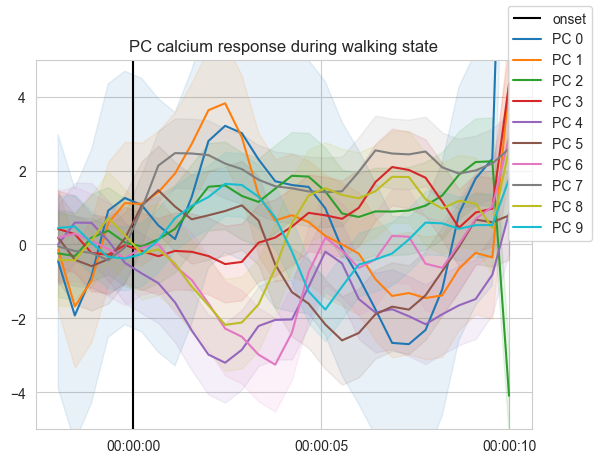

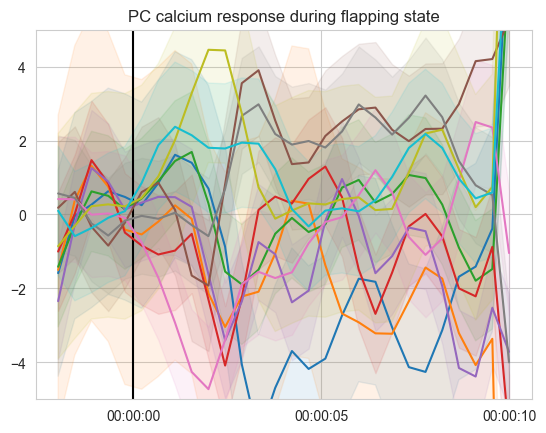

In [258]:
# calculate mean and time coordinates
# FOR WALKING:
walk_psth = pca_walks_onset.mean(dim='trial')
time = walk_psth.coords['time']
# reduce dimensions
walk_psth = walk_psth.squeeze()

# FOR FLAPPING:
flap_psth = pca_flaps_onset.mean(dim='trial')
time = flap_psth.coords['time']
# reduce dimensions
flap_psth = flap_psth.squeeze()

color_list = sns.color_palette('tab10', n_colors=10)

fig, ax = plt.subplots()
onset = np.datetime64('2025-01-01T00:00:00')
ax.vlines(onset, ymin=-10, ymax=10, color='k', label='onset')
# ax.legend(loc='upper right')

for pc in range(walk_psth.shape[1]):
    # calculate mean df/f prelocomotion
    pre = walk_psth.sel(pcs=pc).isel(time=slice(0,6)).mean(dim='time')
    # subtract baseline from trace
    normalized_trace = walk_psth.sel(pcs=pc) - pre
    err = normalized_trace.std(dim='time')

    ax.plot(time, normalized_trace, color=color_list[pc], label = f'PC {pc}')
    ax.set_ylim(-5,5)
    ax.fill_between(time, normalized_trace+err,normalized_trace-err, color=color_list[pc], alpha=0.1)
ax.set_title('PC calcium response during walking state')
fig.legend(loc='outside upper right')

fig2, ax2 = plt.subplots()
onset = np.datetime64('2025-01-01T00:00:00')
ax2.vlines(onset, ymin=-10, ymax=10, color='k', label='onset')


for pc in range(flap_psth.shape[1]):
    # calculate mean df/f prelocomotion
    pre = flap_psth.sel(pcs=pc).isel(time=slice(0,6)).mean(dim='time')
    # subtract baseline from trace
    normalized_trace = flap_psth.sel(pcs=pc) - pre
    err = normalized_trace.std(dim='time')

    ax2.plot(time, normalized_trace, color=color_list[pc], label = f'PC {pc}')
    ax2.set_ylim(-5,5)
    ax2.fill_between(time, normalized_trace+err,normalized_trace-err , color=color_list[pc], alpha=0.1)
ax2.set_title('PC calcium response during flapping state')
# ax2.legend(loc='upper right')
# fig2.legend(loc='outside upper right')

def subtract_baseline(xarray):
    # calculate mean at baseline
    baseline = xarray.sel(dim='pcs').isel(time=slice(0,6)).mean(dim='time')
    return xarray.sel(dim='pcs') - baseline

In [276]:
walk_bouts = [
'2:23',
'8:38'
    ]

flap_bouts = [
'4:28',
'6:20'
    ]

wb_df = build_epoch_df(walk_bouts, 'walks', 5)
fb_df = build_epoch_df(flap_bouts, 'flaps', 5)

# stack with pca data
wb_stacks = stack_epochs(
    xary=pca_transforms,
    epochs=['walks'],
    epoch_df=wb_df,
    start_shift=np.timedelta64(-2, 's'),
    end_shift=np.timedelta64(5, 's')
)
fb_stacks = stack_epochs(
    xary=pca_transforms,
    epochs=['flaps'],
    epoch_df=fb_df,
    start_shift=np.timedelta64(-2, 's'),
    end_shift=np.timedelta64(5, 's')
)

In [257]:
# for psth
walkbout_psth = wb_stacks.mean(dim='trial')
time = walkbout_psth.coords['time']
# reduce dimensions
walkbout_psth = walkbout_psth.squeeze()
walkbout_psth


<xarray.DataArray (time: 28, pcs: 10)> Size: 2kB
array([[-2.67940370e+01,  3.75168435e+01, -1.43328636e+01,
         5.39863404e+00, -4.93927931e+00, -5.34903479e+00,
        -5.30608810e-02,  7.69262897e+00,  1.88882846e-01,
         8.52682914e+00],
       [-2.54042047e+01,  3.76596327e+01, -1.43999144e+01,
         4.88622854e+00, -3.75139693e+00, -5.01962682e+00,
         1.36357284e+00,  7.79501904e+00, -9.36269207e-02,
         8.27247417e+00],
       [-2.22437054e+01,  3.96025685e+01, -1.39640752e+01,
         3.61713936e+00, -2.75172226e+00, -4.94001299e+00,
         1.52105538e+00,  6.11837569e+00, -5.68722918e-01,
         8.27721821e+00],
       [-1.70140276e+01,  4.30988158e+01, -1.30510903e+01,
         1.14872435e+00, -2.12255098e+00, -4.76352174e+00,
         6.47036730e-01,  4.35138534e+00, -9.03716932e-01,
         9.13030885e+00],
       [-1.27606017e+01,  4.54143004e+01, -1.21294112e+01,
         7.75587062e-02, -3.05665290e+00, -3.71725994e+00,
        -6.49187006e-02,  5.07963293e+00, -3.79399973e-01,
         9.90932742e+00],
...
       [-3.60366647e+01,  3.16748448e+01, -1.37297007e+01,
         1.04021787e+01, -5.92456176e+00, -8.17412328e+00,
         3.99570328e-01,  8.31118273e+00,  2.51527451e+00,
         8.00386985e+00],
       [-3.74417948e+01,  3.16180286e+01, -1.51377543e+01,
         9.14234904e+00, -4.33264455e+00, -9.16429335e+00,
         2.93974284e-02,  8.86105790e+00,  1.11072591e+00,
         9.69183924e+00],
       [-3.98860422e+01,  3.13600465e+01, -1.62532504e+01,
         8.44656119e+00, -3.90635791e+00, -9.10760272e+00,
        -6.37329403e-01,  9.05174364e+00,  5.00478139e-01,
         1.10061020e+01],
       [-4.11265240e+01,  3.11222077e+01, -1.61699265e+01,
         9.11118534e+00, -4.74542414e+00, -9.98413836e+00,
        -1.52920816e+00,  8.88488270e+00,  1.35662486e+00,
         1.06674791e+01],
       [-4.01461968e+01,  3.00529721e+01, -1.54196178e+01,
         9.53333016e+00, -5.74475797e+00, -1.25194910e+01,
        -2.12587896e+00,  9.16708959e+00,  1.77857742e+00,
         1.03182316e+01]])
Coordinates:
  * time     (time) datetime64[ms] 224B 2024-12-31T23:59:58 ... 2025-01-01T00...
    epoch    <U5 20B 'walks'
Dimensions without coordinates: pcs

In [293]:
nonwalk_bouts = [
'0:20',
'3:34'
    ]

nonflap_bouts = [
'4:45',
'5:25'
    ]

nw_df = build_epoch_df(nonwalk_bouts, 'walks', 5)
nf_df = build_epoch_df(nonflap_bouts, 'flaps', 5)

# stack with pca data
nw_stacks = stack_epochs(
    xary=pca_transforms,
    epochs=['walks'],
    epoch_df=nw_df,
    start_shift=np.timedelta64(-2, 's'),
    end_shift=np.timedelta64(5, 's')
)
nf_stacks = stack_epochs(
    xary=pca_transforms,
    epochs=['flaps'],
    epoch_df=nf_df,
    start_shift=np.timedelta64(-2, 's'),
    end_shift=np.timedelta64(5, 's')
)

nonwalk_psth = nw_stacks.mean(dim='trial')
time = nonwalk_psth.coords['time']
nonwalk_psth = nonwalk_psth.squeeze()

nonflap_psth = nf_stacks.mean(dim='trial')
time = nonflap_psth.coords['time']
nonflap_psth = nonflap_psth.squeeze()

/Users/princesst/projects/maui_codebook/src/xarray_ops.py:158: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'time' ('time',) The recommendation is to set join explicitly for this case.
  trial_stack = xr.concat(
/Users/princesst/projects/maui_codebook/src/xarray_ops.py:158: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'time' ('time',) The recommendation is to set join explicitly for this case.
  trial_stack = xr.concat(


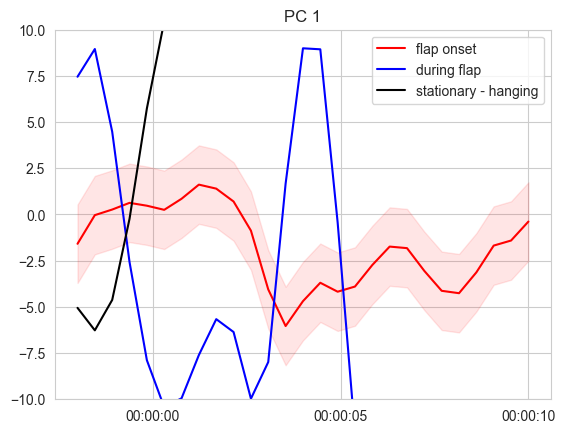

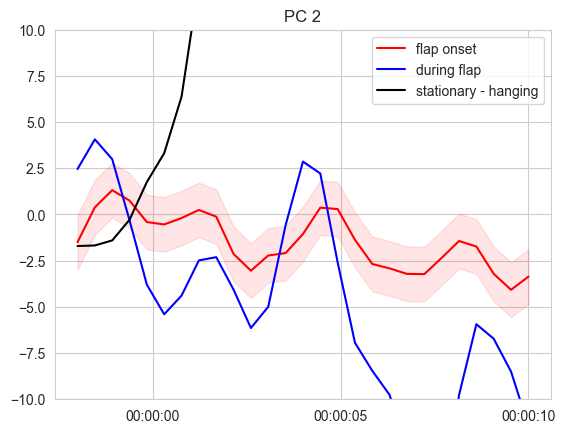

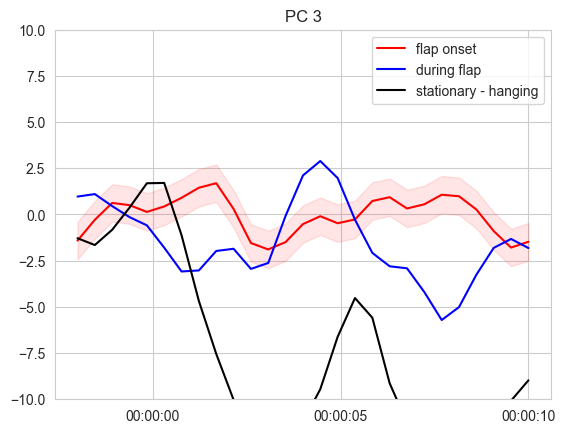

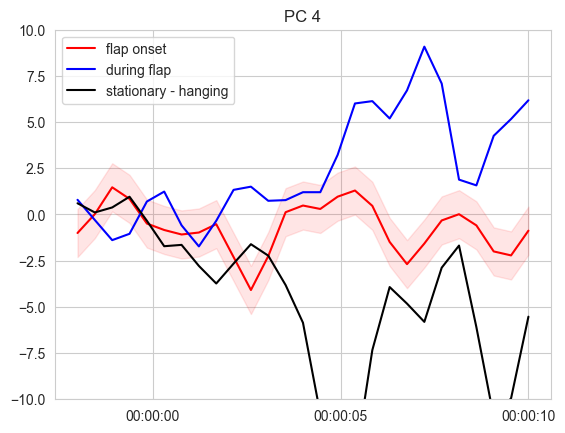

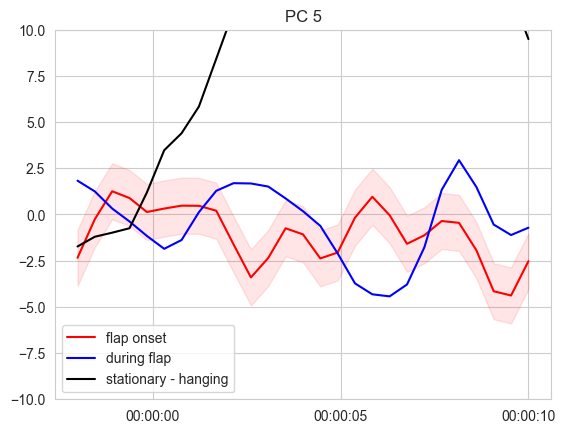

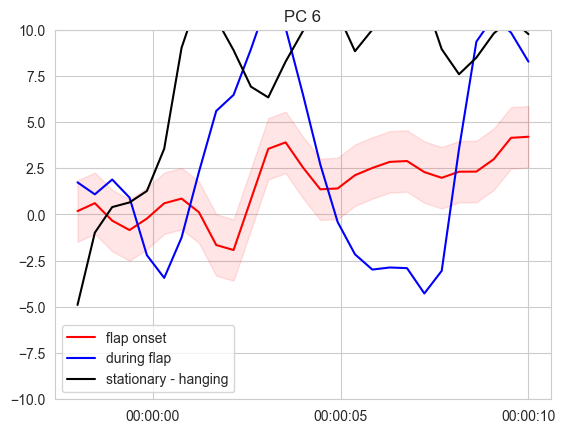

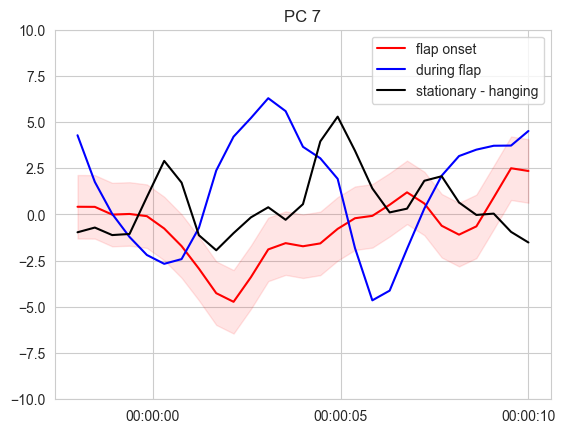

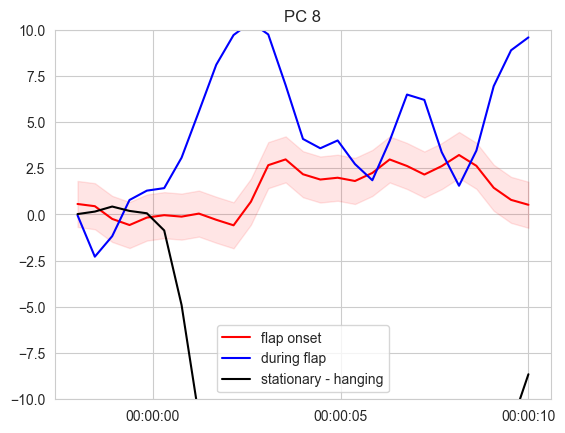

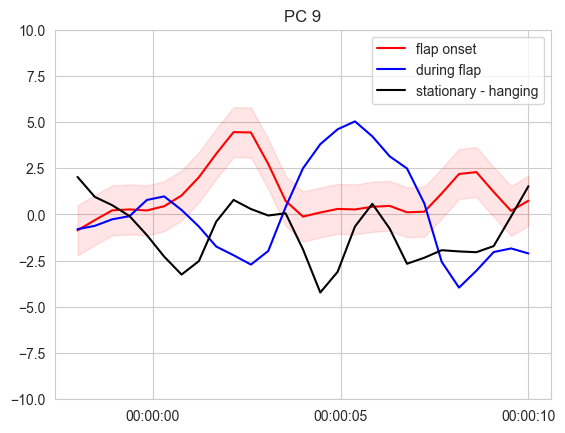

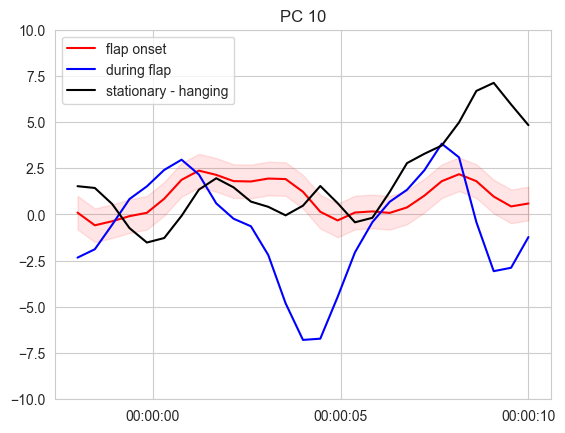

In [306]:
# for psth
flapbout_psth = fb_stacks.mean(dim='trial')
time = flapbout_psth.coords['time']
# reduce dimensions
flapbout_psth = flapbout_psth.squeeze()

for pc in range(flap_psth.shape[1]):
    fig, ax = plt.subplots()
    # calculate mean df/f prelocomotion
    pre = flap_psth.sel(pcs=pc).isel(time=slice(0,6)).mean(dim='time')
    # subtract baseline from trace
    normalized_trace = flap_psth.sel(pcs=pc) - pre
    normalized_trace = normalized_trace[:-1]
    err = normalized_trace.std(dim='time')
    ax.plot(time, normalized_trace, color='r', label = f'flap onset')

    pre_bout = flapbout_psth.sel(pcs=pc).isel(time=slice(0,6)).mean(dim='time')
    normalized_bouts = flapbout_psth.sel(pcs=pc) - pre_bout
    err_bout = normalized_bouts.std(dim='time')
    ax.plot(time, normalized_bouts, color='b', label = 'during flap')

    pre_stationary = nonflap_psth.sel(pcs=pc).isel(time=slice(0,6)).mean(dim='time')
    normalized_nonbouts = nonflap_psth.sel(pcs=pc) - pre_stationary
    normalized_nonbouts = normalized_nonbouts[:-1]
    err_bout = normalized_nonbouts.std(dim='time')
    ax.plot(time, normalized_nonbouts, color='k', label = 'stationary - hanging')

    ax.set_ylim(-10,10)
    ax.fill_between(time, normalized_trace+err,normalized_trace-err, color='r', alpha=0.1)

    ax.set_title(f'PC {pc+1}')
    ax.legend()

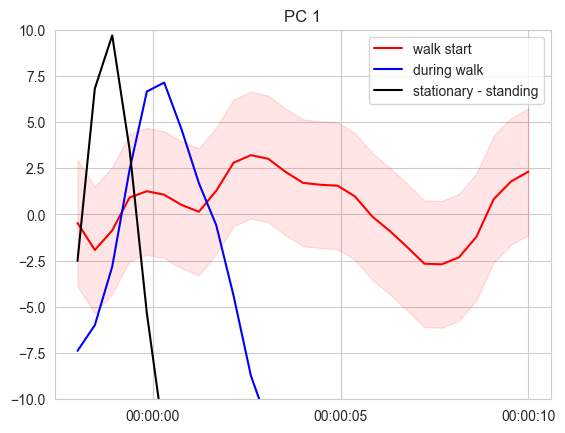

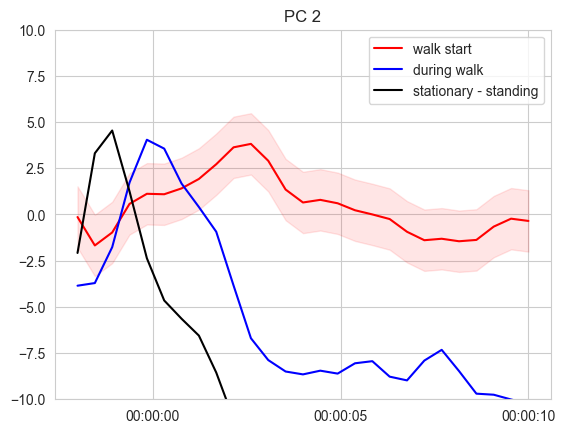

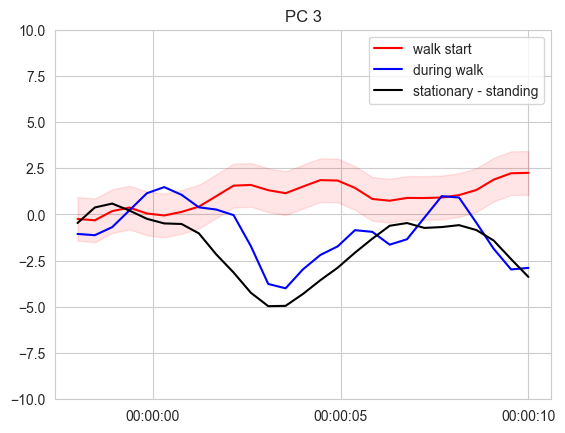

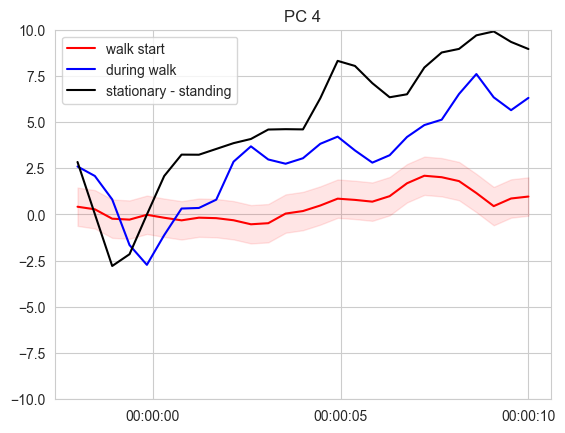

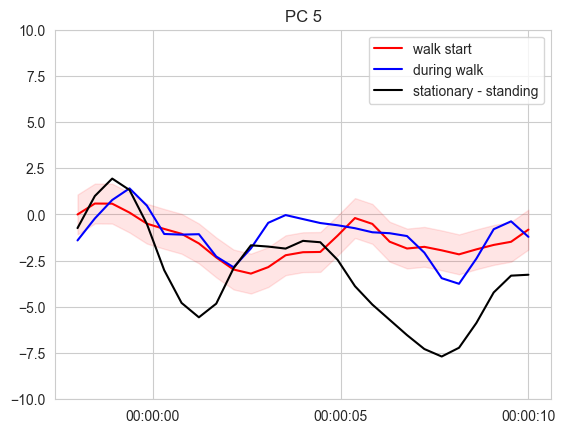

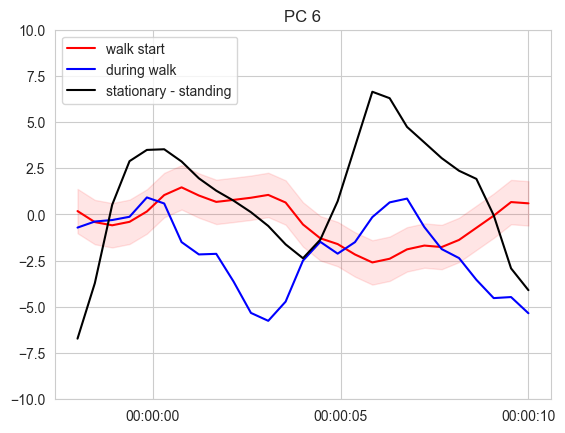

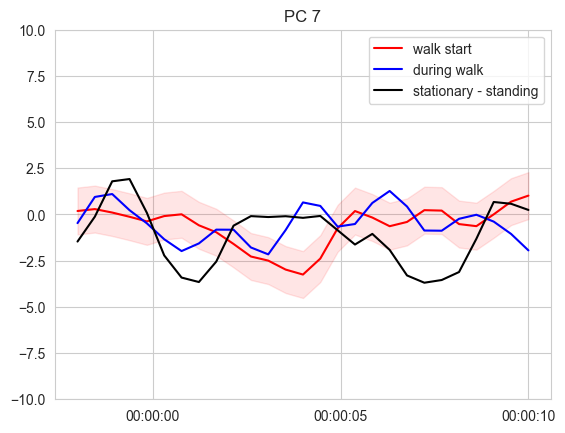

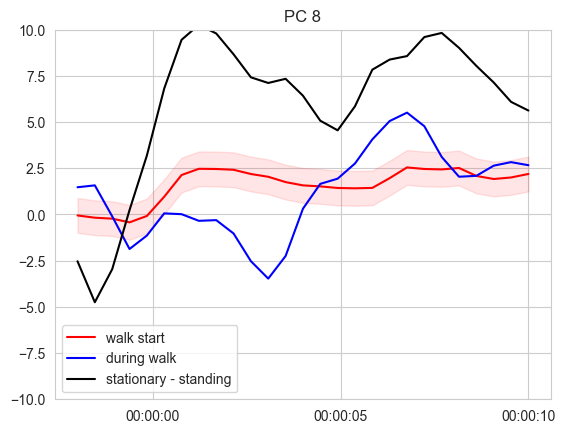

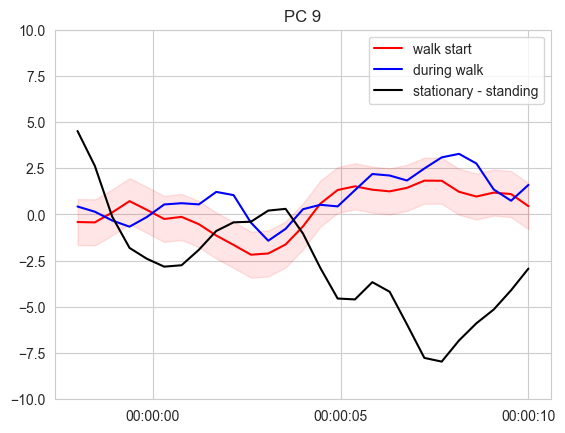

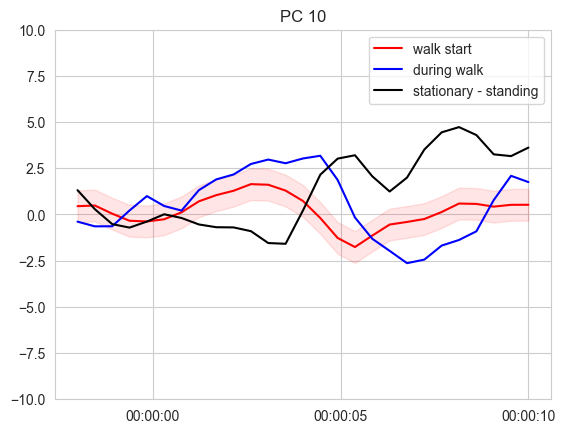

In [305]:
for pc in range(walk_psth.shape[1]):
    fig, ax = plt.subplots()
    # calculate mean df/f prelocomotion
    pre = walk_psth.sel(pcs=pc).isel(time=slice(0,6)).mean(dim='time')
    # subtract baseline from trace
    normalized_trace = walk_psth.sel(pcs=pc) - pre
    err = normalized_trace.std(dim='time')

    pre_bout = walkbout_psth.sel(pcs=pc).isel(time=slice(0,6)).mean(dim='time')
    normalized_bouts = walkbout_psth.sel(pcs=pc) - pre_bout
    err_bout = normalized_bouts.std(dim='time')
    normalized_trace = normalized_trace[:-1]
    normalized_bouts = normalized_bouts[:-1]
    ax.plot(time, normalized_trace, color='r', label = f'walk start')

    ax.fill_between(time, normalized_trace+err,normalized_trace-err , color='r', alpha=0.1)
    ax.plot(time, normalized_bouts, color='b', label = 'during walk')

    pre_stationary = nonwalk_psth.sel(pcs=pc).isel(time=slice(0,6)).mean(dim='time')
    normalized_nonbouts = nonwalk_psth.sel(pcs=pc) - pre_stationary
    normalized_nonbouts = normalized_nonbouts[:-1]
    err_bout = normalized_nonbouts.std(dim='time')
    ax.plot(time, normalized_nonbouts, color='k', label = 'stationary - standing')
    ax.set_title(f'PC {pc+1}')
    ax.legend()
    ax.set_ylim(-10,10)